# 3. Model Experimentation

CNN-BiLSTM-Attention (A5) & Baseline (A4) models as proposed by Zennou et al. (ETASR 2026).

Model architectures are defined natively here before being modularized into the `src/model.py` script.

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.utils.class_weight import compute_class_weight
from datetime import datetime
import json
import random

## Architecture Definitions

In [2]:
@keras.utils.register_keras_serializable()
class SoftAttention(layers.Layer):
    """
    Soft attention mechanism over BiLSTM outputs.

    For each time step t:
        score_t = tanh(W · h_t)          [learned weight vector W]
        alpha_t = softmax(score_t)        [normalised weights]
        context = Σ alpha_t * h_t         [weighted sum]

    This matches the formulation in Zennou et al. (2026), Eq. 5–6.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # W: (feature_dim,) — one weight per feature dimension
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1],),
            initializer="glorot_uniform",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, encoder_output):
        # encoder_output: (batch, T, features)
        score   = tf.nn.tanh(encoder_output * self.W)   # (batch, T, features)
        score   = tf.reduce_sum(score, axis=-1, keepdims=True)  # (batch, T, 1)
        weights = tf.nn.softmax(score, axis=1)           # (batch, T, 1)
        context = tf.reduce_sum(weights * encoder_output, axis=1)  # (batch, features)
        return context, weights

    def get_config(self):
        return super().get_config()


def prelu_block(x, filters: int, kernel_size: int, dropout: float,
                name_prefix: str, l2: float = 1e-4):
    """Conv1D → PReLU → MaxPool(2) → Dropout (paper Table I)."""
    x = layers.Conv1D(
        filters, kernel_size, padding="same",
        kernel_regularizer=regularizers.l2(l2),
        name=f"{name_prefix}_conv"
    )(x)
    x = layers.PReLU(name=f"{name_prefix}_prelu")(x)
    x = layers.MaxPooling1D(2, name=f"{name_prefix}_pool")(x)
    x = layers.Dropout(dropout, name=f"{name_prefix}_drop")(x)
    return x


def build_baseline_model(
    input_shape: tuple,
    n_classes: int,
    conv1_filters: int   = 64,   conv1_kernel: int = 3,
    conv2_filters: int   = 128,  conv2_kernel: int = 5,
    conv3_filters: int   = 256,  conv3_kernel: int = 7,
    lstm_units:    int   = 64,
    dense1_units:  int   = 128,
    dense2_units:  int   = 64,
    dropout_conv:  float = 0.3,
    dropout_dense: float = 0.3,
    l2_reg:        float = 1e-4,
    learning_rate: float = 0.001,
) -> keras.Model:
    """
    Configuration A4 from ETASR paper:
      CNN (3 blocks) + BiLSTM (no attention) → 90.21% on RAVDESS.
    """
    inp = keras.Input(shape=input_shape, name="input_features")

    # CNN blocks
    x = prelu_block(inp, conv1_filters, conv1_kernel, dropout_conv, "conv1", l2=l2_reg)
    x = prelu_block(x,   conv2_filters, conv2_kernel, dropout_conv, "conv2", l2=l2_reg)
    x = prelu_block(x,   conv3_filters, conv3_kernel, dropout_conv, "conv3", l2=l2_reg)

    # BiLSTM — returns final hidden state only (no attention)
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=False,
                    kernel_regularizer=regularizers.l2(l2_reg)), name="bilstm"
    )(x)

    # Dense head
    x   = layers.Dense(dense1_units, kernel_regularizer=regularizers.l2(l2_reg), name="dense1")(x)
    x   = layers.PReLU(name="dense1_prelu")(x)
    x   = layers.Dropout(dropout_dense, name="drop_dense1")(x)
    x   = layers.Dense(dense2_units, kernel_regularizer=regularizers.l2(l2_reg), name="dense2")(x)
    x   = layers.PReLU(name="dense2_prelu")(x)
    x   = layers.Dropout(dropout_dense, name="drop_dense2")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inp, outputs=out, name="CNN_BiLSTM_A4")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_attention_model(
    input_shape: tuple,
    n_classes: int,
    conv1_filters: int   = 64,   conv1_kernel: int = 3,
    conv2_filters: int   = 128,  conv2_kernel: int = 5,
    conv3_filters: int   = 256,  conv3_kernel: int = 7,
    lstm_units:    int   = 64,
    dense1_units:  int   = 128,
    dense2_units:  int   = 64,
    dropout_conv:  float = 0.3,
    dropout_dense: float = 0.3,
    l2_reg:        float = 1e-4,
    learning_rate: float = 0.001,
) -> keras.Model:
    """
    Configuration A5 — proposed model from ETASR paper:
      CNN (3 blocks) + BiLSTM + Soft Attention → 91.74% on RAVDESS.
    """
    inp = keras.Input(shape=input_shape, name="input_features")

    # CNN blocks (3 × PReLU + MaxPool + Dropout)
    x = prelu_block(inp, conv1_filters, conv1_kernel, dropout_conv, "conv1", l2=l2_reg)
    x = prelu_block(x,   conv2_filters, conv2_kernel, dropout_conv, "conv2", l2=l2_reg)
    x = prelu_block(x,   conv3_filters, conv3_kernel, dropout_conv, "conv3", l2=l2_reg)

    # BiLSTM — returns sequences for attention
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True,
                    kernel_regularizer=regularizers.l2(l2_reg)), name="bilstm"
    )(x)

    # Soft attention
    context, _ = SoftAttention(name="attention")(x)

    # Dense head
    x   = layers.Dense(dense1_units, kernel_regularizer=regularizers.l2(l2_reg), name="dense1")(context)
    x   = layers.PReLU(name="dense1_prelu")(x)
    x   = layers.Dropout(dropout_dense, name="drop_dense1")(x)
    x   = layers.Dense(dense2_units, kernel_regularizer=regularizers.l2(l2_reg), name="dense2")(x)
    x   = layers.PReLU(name="dense2_prelu")(x)
    x   = layers.Dropout(dropout_dense, name="drop_dense2")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inp, outputs=out, name="CNN_BiLSTM_Attention_A5")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


## Load Dataset

In [3]:
X_train = np.load('../data/processed/features/train/X.npy')
y_train = np.load('../data/processed/features/train/y.npy')
X_test = np.load('../data/processed/features/test/X.npy')
y_test = np.load('../data/processed/features/test/y.npy')

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(10800, 400, 40), y=(10800,)
Test shapes: X=(240, 400, 40), y=(240,)


## Build Models

In [4]:
input_shape = (400, 40)
n_classes = len(np.unique(y_train))

baseline_model = build_baseline_model(input_shape, n_classes)
attention_model = build_attention_model(input_shape, n_classes)

print("=== Baseline A4 ===")
baseline_model.summary()
print("\n=== Attention A5 ===")
attention_model.summary()

2026-05-22 15:30:27.579091: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-22 15:30:27.579135: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-22 15:30:27.579324: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-22 15:30:27.579353: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-22 15:30:27.579364: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


=== Baseline A4 ===


Model: "CNN_BiLSTM_A4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 400, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_conv (Conv1D)             │ (None, 400, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_prelu (PReLU)             │ (None, 400, 64)        │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_pool (MaxPooling1D)       │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_drop (Dropout)            │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_conv (Conv1D)             │ (None, 200, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_prelu (PReLU)             │ (None, 200, 128)       │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_pool (MaxPooling1D)       │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_drop (Dropout)            │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_conv (Conv1D)             │ (None, 100, 256)       │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_prelu (PReLU)             │ (None, 100, 256)       │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_pool (MaxPooling1D)       │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_drop (Dropout)            │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1_prelu (PReLU)            │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense1 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2_prelu (PReLU)            │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense2 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,096 (2.08 MB)

...

Model: "CNN_BiLSTM_Attention_A5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 400, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_conv (Conv1D)             │ (None, 400, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_prelu (PReLU)             │ (None, 400, 64)        │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_pool (MaxPooling1D)       │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_drop (Dropout)            │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_conv (Conv1D)             │ (None, 200, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_prelu (PReLU)             │ (None, 200, 128)       │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_pool (MaxPooling1D)       │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_drop (Dropout)            │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_conv (Conv1D)             │ (None, 100, 256)       │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_prelu (PReLU)             │ (None, 100, 256)       │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_pool (MaxPooling1D)       │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_drop (Dropout)            │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 50, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (SoftAttention)       │ [(None, 128), (None,   │           128 │
│                                 │ 50, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1_prelu (PReLU)            │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense1 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2_prelu (PReLU)            │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense2 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,224 (2.08 MB)

 Trainable params: 545,224 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [5]:
BASE_DIR      = os.path.dirname("/Users/wandika/dibimbing/Final Project/notebooks")
FEATURES_DIR  = os.path.join(BASE_DIR, "data", "processed", "features")
MODELS_DIR    = os.path.join(BASE_DIR, "models")

def load_split(split_name: str) -> tuple:
    """Load pre-extracted feature arrays for a given split (train/val/test)."""
    split_dir = os.path.join(FEATURES_DIR, split_name)
    X = np.load(os.path.join(split_dir, "X.npy"))
    y = np.load(os.path.join(split_dir, "y.npy"))
    return X, y

def get_callbacks(model_name: str,
                  patience_es: int = 20,
                  patience_lr: int = 10):
    """Return standard Keras callbacks (ETASR paper config)."""
    ckpt_path = os.path.join(MODELS_DIR, f"{model_name}_best.keras")
    return [
        # Paper: early stopping based on validation loss
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience_es,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-6,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
        ),
    ]

In [6]:
def train(
    model_type: str = "attention",
    epochs:     int   = 300,
    batch_size: int   = 32,
    **hparams,
) -> tuple:
    """
    Load data, build model, compute class weights, and train.

    Returns
    -------
    (model, history, timestamp)
    """
    print(f"\n{'='*60}")
    print(f"  Training: {model_type.upper()} model  (ETASR config)")
    print(f"  epochs={epochs}, batch_size={batch_size}")
    print(f"{'='*60}")

    # ── Load data ──────────────────────────────────────────────────────────────
    X_train, y_train = load_split("train")
    X_val,   y_val   = load_split("val")
    print(f"Train : X={X_train.shape}, y={y_train.shape}")
    print(f"Val   : X={X_val.shape},   y={y_val.shape}")

    n_classes   = len(np.unique(y_train))
    input_shape = X_train.shape[1:]   # (400, 40)

    # ── Class weights ──────────────────────────────────────────────────────────
    cw_vals = compute_class_weight(
        "balanced", classes=np.unique(y_train), y=y_train
    )
    class_weights = dict(enumerate(cw_vals))
    print(f"\nClass weights: { {k: round(v, 3) for k, v in class_weights.items()} }")

    # ── Build model ────────────────────────────────────────────────────────────
    if model_type == "baseline":
        model = build_baseline_model(input_shape, n_classes, **hparams)
    else:
        model = build_attention_model(input_shape, n_classes, **hparams)

    model.summary(line_length=100)

    # ── Train ──────────────────────────────────────────────────────────────────
    ts        = datetime.now().strftime("%Y%m%d_%H%M%S")
    callbacks = get_callbacks(f"{model_type}_{ts}")

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1,
    )

    # ── Save final model & history ─────────────────────────────────────────────
    final_path = os.path.join(MODELS_DIR, f"{model_type}_{ts}_final.keras")
    model.save(final_path)

    hist_path = os.path.join(MODELS_DIR, f"{model_type}_{ts}_history.json")
    hist_dict = {k: [float(v) for v in vals]
                 for k, vals in history.history.items()}
    with open(hist_path, "w") as f:
        json.dump(hist_dict, f, indent=2)

    print(f"\nModel saved   → {final_path}")
    print(f"History saved → {hist_path}")
    return model, history, ts

In [7]:
train(model_type="baseline")


  Training: BASELINE model  (ETASR config)
  epochs=300, batch_size=32
Train : X=(10800, 400, 40), y=(10800,)
Val   : X=(480, 400, 40),   y=(480,)

Class weights: {0: 0.938, 1: 0.938, 2: 0.938, 3: 0.938, 4: 0.938, 5: 1.875, 6: 0.938, 7: 0.938}


Model: "CNN_BiLSTM_A4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)                │ (None, 400, 40)                 │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv1_conv (Conv1D)                        │ (None, 400, 64)                 │             7,744 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv1_prelu (PReLU)                        │ (None, 400, 64)                 │            25,600 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv1_pool (MaxPooling1D)                  │ (None, 200, 64)                 │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv1_drop (Dropout)                       │ (None, 200, 64)                 │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2_conv (Conv1D)                        │ (None, 200, 128)                │            41,088 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2_prelu (PReLU)                        │ (None, 200, 128)                │            25,600 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2_pool (MaxPooling1D)                  │ (None, 100, 128)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2_drop (Dropout)                       │ (None, 100, 128)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3_conv (Conv1D)                        │ (None, 100, 256)                │           229,632 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3_prelu (PReLU)                        │ (None, 100, 256)                │            25,600 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3_pool (MaxPooling1D)                  │ (None, 50, 256)                 │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3_drop (Dropout)                       │ (None, 50, 256)                 │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ bilstm (Bidirectional)                     │ (None, 128)                     │           164,352 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense1 (Dense)                             │ (None, 128)                     │            16,512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense1_prelu (PReLU)                       │ (None, 128)                     │               128 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ drop_dense1 (Dropout)                      │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense2 (Dense)                             │ (None, 64)                      │             8,256 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense2_prelu (PReLU)                       │ (None, 64)    

 Total params: 545,096 (2.08 MB)

 Trainable params: 545,096 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300


2026-05-22 15:30:29.578279: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1402 - loss: 2.1576
Epoch 1: val_accuracy improved from None to 0.28750, saving model to /Users/wandika/dibimbing/Final Project/models/baseline_20260522_153028_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.1818 - loss: 2.0748 - val_accuracy: 0.2875 - val_loss: 1.8005 - learning_rate: 0.0010
Epoch 2/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2982 - loss: 1.8037
Epoch 2: val_accuracy improved from 0.28750 to 0.43333, saving model to /Users/wandika/dibimbing/Final Project/models/baseline_20260522_153028_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.3338 - loss: 1.7327 - val_accuracy: 0.4333 - val_loss: 1.6153 - learning_rate: 0.0010
Epoch 3/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4362 - loss: 1.5292
Epoch 3: val_accuracy improved from 0.43333 to 0.47083, saving model to /Users/wandika/dibimbing/Final Project/models/baseline_20260522_153028_best.keras
338

(<Functional name=CNN_BiLSTM_A4, built=True>,
 '20260522_153028')

In [8]:
train(model_type="attention")


  Training: ATTENTION model  (ETASR config)
  epochs=300, batch_size=32
Train : X=(10800, 400, 40), y=(10800,)
Val   : X=(480, 400, 40),   y=(480,)

Class weights: {0: 0.938, 1: 0.938, 2: 0.938, 3: 0.938, 4: 0.938, 5: 1.875, 6: 0.938, 7: 0.938}


Model: "CNN_BiLSTM_Attention_A5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)                │ (None, 400, 40)                 │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv1_conv (Conv1D)                        │ (None, 400, 64)                 │             7,744 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv1_prelu (PReLU)                        │ (None, 400, 64)                 │            25,600 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv1_pool (MaxPooling1D)                  │ (None, 200, 64)                 │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv1_drop (Dropout)                       │ (None, 200, 64)                 │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2_conv (Conv1D)                        │ (None, 200, 128)                │            41,088 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2_prelu (PReLU)                        │ (None, 200, 128)                │            25,600 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2_pool (MaxPooling1D)                  │ (None, 100, 128)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2_drop (Dropout)                       │ (None, 100, 128)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3_conv (Conv1D)                        │ (None, 100, 256)                │           229,632 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3_prelu (PReLU)                        │ (None, 100, 256)                │            25,600 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3_pool (MaxPooling1D)                  │ (None, 50, 256)                 │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3_drop (Dropout)                       │ (None, 50, 256)                 │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ bilstm (Bidirectional)                     │ (None, 50, 128)                 │           164,352 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ attention (SoftAttention)                  │ [(None, 128), (None, 50, 1)]    │               128 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense1 (Dense)                             │ (None, 128)                     │            16,512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense1_prelu (PReLU)                       │ (None, 128)                     │               128 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ drop_dense1 (Dropout)                      │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense2 (Dense)                             │ (None, 64)    

 Total params: 545,224 (2.08 MB)

 Trainable params: 545,224 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.1656 - loss: 2.1100
Epoch 1: val_accuracy improved from None to 0.35833, saving model to /Users/wandika/dibimbing/Final Project/models/attention_20260522_153626_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.2196 - loss: 1.9735 - val_accuracy: 0.3583 - val_loss: 1.7517 - learning_rate: 0.0010
Epoch 2/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3686 - loss: 1.6348
Epoch 2: val_accuracy improved from 0.35833 to 0.45833, saving model to /Users/wandika/dibimbing/Final Project/models/attention_20260522_153626_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.4018 - loss: 1.5534 - val_accuracy: 0.4583 - val_loss: 1.5096 - learning_rate: 0.0010
Epoch 3/300
337/338 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4822 - loss: 1.3572
Epoch 3: val_accuracy improved from 0.45833 to 0.49167, saving model to /Users/wandika/dibimbing/Final Project/models/attention_20260522_153626

(<Functional name=CNN_BiLSTM_Attention_A5, built=True>,
 '20260522_153626')

# Hyperparameter Tuning

In [ ]:
SEARCH_SPACE = {
    "conv1_filters":  [64, 128],
    "conv2_filters":  [128, 256],
    "conv3_filters":  [256, 512],
    "lstm_units":     [64, 128],
    "dense1_units":   [128, 256],
    "dense2_units":   [64, 128],
    "dropout_conv":   [0.2, 0.3, 0.4],
    "dropout_dense":  [0.2, 0.3, 0.4],
    "learning_rate":  [0.0001, 0.001],
    "batch_size":     [16, 32],
}

def random_search(n_trials: int = 10, epochs: int = 50) -> dict:
    """Run n_trials of random hyperparameter search and return best params."""
    X_train, y_train = load_split("train")
    X_val,   y_val   = load_split("val")
    n_classes   = len(np.unique(y_train))
    input_shape = X_train.shape[1:]

    cw_vals       = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(cw_vals))

    best_val_acc = 0.0
    best_params  = {}
    results      = []

    for trial in range(1, n_trials + 1):
        params     = {k: random.choice(v) for k, v in SEARCH_SPACE.items()}
        batch_size = params.pop("batch_size")

        print(f"\n{'─'*60}")
        print(f"Trial {trial}/{n_trials}: {params}")

        model = build_attention_model(input_shape, n_classes, **params)
        cb = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=10, restore_best_weights=True
            ),
        ]
        hist = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weights,
            callbacks=cb,
            verbose=0,
        )

        final_path = os.path.join(MODELS_DIR, f"tuned_{ts}_final.keras")
        model.save(final_path)

        hist_path = os.path.join(MODELS_DIR, f"tuned_{ts}_history.json")
        hist_dict = {k: [float(v) for v in vals]
                    for k, vals in hist.history.items()}
        
        with open(hist_path, "w") as f:
            json.dump(hist_dict, f, indent=2)

        val_acc = max(hist.history["val_accuracy"])
        print(f"  → best val_accuracy: {val_acc:.4f}")
        results.append({
            "params":   {**params, "batch_size": batch_size},
            "val_acc":  val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params  = {**params, "batch_size": batch_size}
            best_model   = model

        keras.backend.clear_session()

    # Save results
    ts           = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_path = os.path.join(MODELS_DIR, f"best_tuned_{ts}.json")
    with open(results_path, "w") as f:
        json.dump({
            "best_val_acc": best_val_acc,
            "best_params":  best_params,
            "all_results":  results,
        }, f, indent=2)

    best_model.save(os.path.join(MODELS_DIR, f"best_tuned_{ts}.keras"))
    print(f"\n{'='*60}")
    print(f"Best val_accuracy : {best_val_acc:.4f}")
    print(f"Best params       : {best_params}")
    print(f"Results saved     → {results_path}")

    
    return best_params

In [10]:
random_search(n_trials=10, epochs=50)


────────────────────────────────────────────────────────────
Trial 1/10: {'conv1_filters': 64, 'conv2_filters': 128, 'conv3_filters': 256, 'lstm_units': 64, 'dense1_units': 256, 'dense2_units': 128, 'dropout_conv': 0.4, 'dropout_dense': 0.2, 'learning_rate': 0.001}
  → best val_accuracy: 0.5708

────────────────────────────────────────────────────────────
Trial 2/10: {'conv1_filters': 64, 'conv2_filters': 256, 'conv3_filters': 256, 'lstm_units': 64, 'dense1_units': 128, 'dense2_units': 128, 'dropout_conv': 0.3, 'dropout_dense': 0.3, 'learning_rate': 0.0001}
  → best val_accuracy: 0.5708

────────────────────────────────────────────────────────────
Trial 3/10: {'conv1_filters': 64, 'conv2_filters': 256, 'conv3_filters': 512, 'lstm_units': 64, 'dense1_units': 128, 'dense2_units': 128, 'dropout_conv': 0.4, 'dropout_dense': 0.4, 'learning_rate': 0.0001}
  → best val_accuracy: 0.5708

────────────────────────────────────────────────────────────
Trial 4/10: {'conv1_filters': 64, 'conv2_filt

{'conv1_filters': 128,
 'conv2_filters': 256,
 'conv3_filters': 256,
 'lstm_units': 128,
 'dense1_units': 256,
 'dense2_units': 64,
 'dropout_conv': 0.3,
 'dropout_dense': 0.3,
 'learning_rate': 0.0001,
 'batch_size': 16}

In [11]:
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
history_files = sorted(glob.glob('../models/*history*.json'))
histories = {}

for f in history_files:
    # Example filename: attention_20260522_141951_history.json
    model_name = os.path.basename(f).split('_')[0]
    # Distinguish if there's a tuned version
    if 'tuned' in f:
        model_name += '_tuned'
        
    with open(f, 'r') as fp:
        histories[model_name] = json.load(fp)

print(f"Loaded histories for: {list(histories.keys())}")

Loaded histories for: ['attention', 'baseline', 'tuned_tuned']



attention - Final val_accuracy:

baseline - Final val_accuracy:

tuned_tuned - Final val_accuracy:


KeyError: 'accuracy'

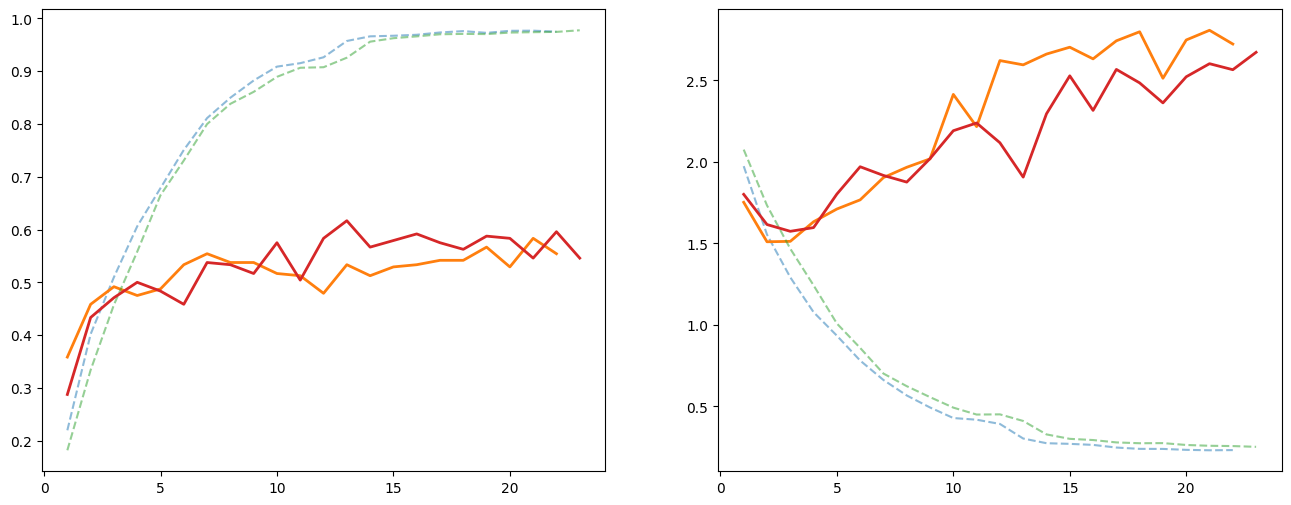

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, hist in histories.items():
    print(f"\n{name} - Final val_accuracy: {hist['val_accuracy'][-1]:.4f}")
    epochs = range(1, len(hist['accuracy']) + 1)
    
    # Accuracy Plot
    axes[0].plot(epochs, hist['accuracy'], linestyle='--', alpha=0.5, label=f'{name} (Train)')
    axes[0].plot(epochs, hist['val_accuracy'], linewidth=2, label=f'{name} (Val)')
    
    # Loss Plot
    axes[1].plot(epochs, hist['loss'], linestyle='--', alpha=0.5, label=f'{name} (Train)')
    axes[1].plot(epochs, hist['val_loss'], linewidth=2, label=f'{name} (Val)')

axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

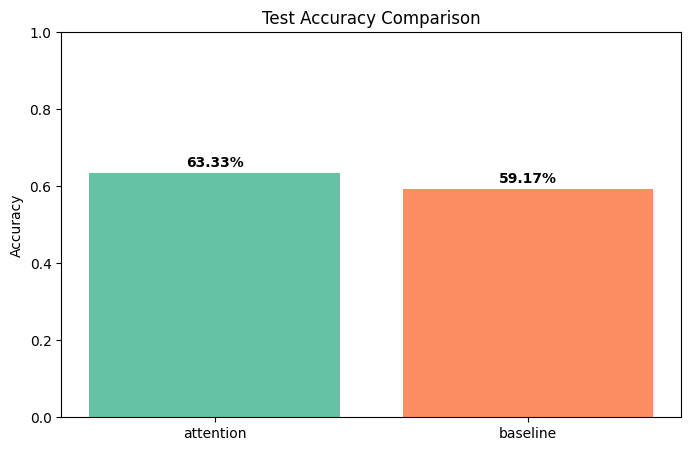

In [17]:
X_test = np.load('../data/processed/features/test/X.npy')
y_test = np.load('../data/processed/features/test/y.npy')

model_files = sorted(glob.glob('../models/*best.keras'))
test_results = {}

for m_file in model_files:
    model_name = os.path.basename(m_file).split('_')[0]
    if 'tuned' in m_file:
        model_name += '_tuned'
        
    model = tf.keras.models.load_model(m_file, custom_objects={'SoftAttention': SoftAttention}, compile=False)
    model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    test_results[model_name] = acc

# Plotting Test Accuracies
plt.figure(figsize=(8, 5))
names = list(test_results.keys())
accuracies = list(test_results.values())

bars = plt.bar(names, accuracies, color=sns.color_palette("Set2"))
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)

# Add text labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

plt.show()